# Cell 1: Imports and Configuration

In [1]:
import random
import warnings
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import timm
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    classification_report, roc_auc_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score,
)
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

HASH_BITS = 128
BATCH_SIZE = 32
IMG_SIZE = 224
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

EPOCHS_FROZEN = 5
EPOCHS_FINETUNE = 15
LR_HEAD = 3e-4
LR_BACKBONE = 1e-5
WEIGHT_DECAY = 1e-4
PATIENCE = 6
LOSS_SLACK = 0.02

LAMBDA_CLS = 1.0
LAMBDA_CSQ = 1.5
LAMBDA_DIV = 0.3
LAMBDA_QUANT = 0.5
LAMBDA_BALAN = 0.5
CSQ_SCALE = 2.0
TARGET_INTRA_D = HASH_BITS / 2.0 # From HASH_BITS / 4.0 -> HASH_BITS / 2.0

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
  GPU : Tesla T4
  VRAM: 15.6 GB


# Cell 2: Dataset Loading

In [2]:
import kagglehub

path = kagglehub.dataset_download("divg07/casia-20-image-tampering-detection-dataset")
DATA_ROOT = Path(path) / "CASIA2"

au_paths = sorted(p for p in (DATA_ROOT / "Au").iterdir() if p.suffix.lower() in IMG_EXTS)
tp_paths = sorted(p for p in (DATA_ROOT / "Tp").iterdir() if p.suffix.lower() in IMG_EXTS)

all_paths = au_paths + tp_paths
all_labels = [0] * len(au_paths) + [1] * len(tp_paths)

indices = list(range(len(all_paths)))
idx_tv, idx_test = train_test_split(indices, test_size=0.15, stratify=all_labels, random_state=SEED)
labels_tv = [all_labels[i] for i in idx_tv]
idx_train, idx_val = train_test_split(idx_tv, test_size=0.15 / 0.85, stratify=labels_tv, random_state=SEED)

train_paths = [all_paths[i] for i in idx_train]
train_labels = [all_labels[i] for i in idx_train]
val_paths = [all_paths[i] for i in idx_val]
val_labels = [all_labels[i] for i in idx_val]
test_paths = [all_paths[i] for i in idx_test]
test_labels = [all_labels[i] for i in idx_test]

for name, lbl in [("Train", train_labels), ("Val", val_labels), ("Test", test_labels)]:
    print(f"{name:5s}: total={len(lbl):4d}  Au={lbl.count(0):4d}  Tp={lbl.count(1):4d}")

Using Colab cache for faster access to the 'casia-20-image-tampering-detection-dataset' dataset.
Train: total=8829  Au=5243  Tp=3586
Val  : total=1892  Au=1124  Tp= 768
Test : total=1893  Au=1124  Tp= 769


# Cell 2b: Dataset Split Visualization

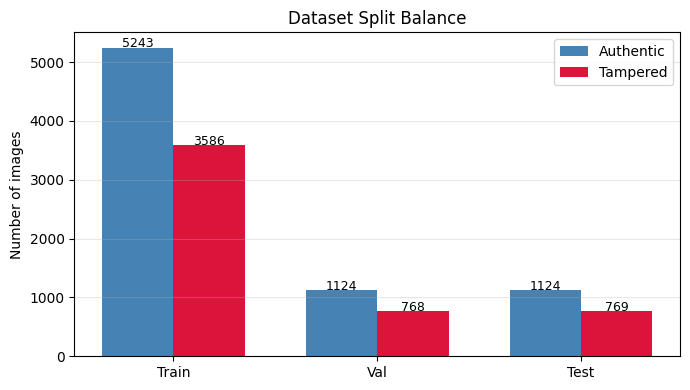

In [3]:
split_names = ["Train", "Val", "Test"]
split_labels = [train_labels, val_labels, test_labels]
au_counts = [lbl.count(0) for lbl in split_labels]
tp_counts = [lbl.count(1) for lbl in split_labels]

x = np.arange(len(split_names))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width / 2, au_counts, width, label="Authentic", color="steelblue")
ax.bar(x + width / 2, tp_counts, width, label="Tampered", color="crimson")
for i, (a, t) in enumerate(zip(au_counts, tp_counts)):
    ax.text(i - width / 2, a + 5, str(a), ha="center", fontsize=9)
    ax.text(i + width / 2, t + 5, str(t), ha="center", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(split_names)
ax.set_ylabel("Number of images")
ax.set_title("Dataset Split Balance")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("dataset_split.png", dpi=150, bbox_inches="tight")
plt.show()

# Cell 3: Dataset and DataLoaders

In [4]:
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.08),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

NUM_IN_CHANNELS = 3


class CASIADataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img), torch.tensor(self.labels[idx], dtype=torch.long)


train_dataset = CASIADataset(train_paths, train_labels, train_tf)
val_dataset = CASIADataset(val_paths, val_labels, eval_tf)
test_dataset = CASIADataset(test_paths, test_labels, eval_tf)

counts_arr = np.array([train_labels.count(0), train_labels.count(1)], dtype=np.float32)
sample_weights = torch.tensor([1.0 / counts_arr[l] for l in train_labels])
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                           num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Input channels: {NUM_IN_CHANNELS}  (RGB + SRM residual)")

Train batches : 276
Val   batches : 60
Input channels: 3  (RGB + SRM residual)


# Cell 4: Model Architecture

In [5]:
class ForensicHashNet(nn.Module):
    """
    EfficientNet-B0 backbone, 3-channel RGB input only.

    Ablation: SRM forensic stream removed entirely — no extra input
    channel, no srm_stream branch, fusion collapses to backbone
    features alone.

    The classification head branches from the fused features, not from
    the hash, so classification gradients do not reshape the hash code.
    """
    def __init__(self, hash_bits: int = HASH_BITS, num_classes: int = 2,
                 n_in: int = NUM_IN_CHANNELS):
        super().__init__()

        backbone = timm.create_model("efficientnet_b0", pretrained=True,
                                      num_classes=0, global_pool="avg")
        # n_in == 3 matches the pretrained conv_stem natively — no
        # channel-splicing needed (unlike the 4-channel baseline).
        self.backbone = backbone
        feat_dim = backbone.num_features

        self.fusion = nn.Sequential(
            nn.Linear(feat_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.GELU(),
            nn.Dropout(0.4),
        )

        self.hash_head = nn.Sequential(
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, hash_bits),
            nn.BatchNorm1d(hash_bits),
        )

        self.cls_head = nn.Sequential(
            nn.Linear(1024, num_classes),
        )

    def forward(self, x: torch.Tensor):
        sem = self.backbone(x)
        fused = self.fusion(sem)
        h = torch.tanh(self.hash_head(fused))
        logits = self.cls_head(fused)
        return h, logits

    def get_binary_hash(self, x: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            h, _ = self.forward(x)
        return h.sign()

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad_(False)

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad_(True)


model = ForensicHashNet(hash_bits=HASH_BITS).to(DEVICE)
with torch.no_grad():
    _h, _l = model(torch.randn(2, NUM_IN_CHANNELS, IMG_SIZE, IMG_SIZE).to(DEVICE))
print(f"Hash shape  : {_h.shape}")
print(f"Logits shape: {_l.shape}")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6:.2f}M")

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Hash shape  : torch.Size([2, 128])
Logits shape: torch.Size([2, 2])
Trainable params: 5.92M


# Cell 5: Hash Loss

In [6]:
class ForensicHashLoss(nn.Module):
    """
    Combined hash loss with two parts.

    CSQ pulls each hash toward its class center and away from the other
    center, using fixed binary centers at maximum Hamming distance.

    IntraDiversity penalizes same-class pairs that are closer than a
    target Hamming distance, which keeps the hash from collapsing to a
    single code per class.
    """
    def __init__(self, hash_bits: int = HASH_BITS, num_classes: int = 2,
                 scale: float = CSQ_SCALE, target_d: float = TARGET_INTRA_D):
        super().__init__()
        self.K = hash_bits
        self.scale = scale
        self.target_d = target_d

        centers = torch.zeros(num_classes, hash_bits)
        centers[0, :hash_bits // 2] = 1.0
        centers[0, hash_bits // 2:] = -1.0
        centers[1] = -centers[0]
        self.register_buffer("centers", centers)

    def forward(self, h: torch.Tensor, labels: torch.Tensor):
        B = h.size(0)

        sim = h @ self.centers.T / self.K
        own_sim = sim[torch.arange(B), labels]
        other_sim = sim[torch.arange(B), 1 - labels]
        csq_loss = (
            -F.logsigmoid(self.scale * own_sim) +
            -F.logsigmoid(-self.scale * other_sim)
        ).mean()

        ip = h @ h.T
        d = (self.K - ip) / 2.0
        off_diag = 1 - torch.eye(B, device=h.device)
        same_mask = (labels.unsqueeze(0) == labels.unsqueeze(1)).float() * off_diag
        div_loss = (F.relu(self.target_d - d) ** 2 * same_mask).sum() / (same_mask.sum() + 1e-8)

        quant_loss = (h.abs() - 1).pow(2).mean()
        balance_loss = h.mean(dim=0).pow(2).mean()

        return csq_loss, div_loss, quant_loss, balance_loss


hash_loss_fn = ForensicHashLoss(hash_bits=HASH_BITS).to(DEVICE)

with torch.no_grad():
    c = hash_loss_fn.centers
    hd = (c[0] != c[1]).float().sum().item()
print(f"Center Hamming distance : {hd:.0f} / {HASH_BITS} bits  (should be {HASH_BITS})")
print(f"CSQ scale               : {CSQ_SCALE}")
print(f"IntraDiversity target   : {TARGET_INTRA_D:.0f} bits")

h_test = torch.ones(4, HASH_BITS, device=DEVICE) * 0.9
lbl_t = torch.zeros(4, dtype=torch.long, device=DEVICE)
h_test.requires_grad_(True)
_, dl, _, _ = hash_loss_fn(h_test, lbl_t)
dl.backward()
grad_at_collapse = h_test.grad.abs().mean().item()
print(f"Div gradient at collapse: {grad_at_collapse:.4f}  (should be well above 0)")

Center Hamming distance : 128 / 128 bits  (should be 128)
CSQ scale               : 2.0
IntraDiversity target   : 64 bits
Div gradient at collapse: 23.3280  (should be well above 0)


# Cell 6: Training Utilities

In [7]:
def compute_loss(h, logits, labels):
    l_cls = F.cross_entropy(logits, labels, label_smoothing=0.05)
    l_csq, l_div, l_q, l_b = hash_loss_fn(h, labels)
    total = (LAMBDA_CLS * l_cls
             + LAMBDA_CSQ * l_csq
             + LAMBDA_DIV * l_div
             + LAMBDA_QUANT * l_q
             + LAMBDA_BALAN * l_b)
    parts = {
        "cls": l_cls.item(),
        "csq": l_csq.item(),
        "div": l_div.item(),
        "quant": l_q.item(),
        "balance": l_b.item(),
    }
    return total, parts


def run_epoch(model, loader, optimizer=None, desc=""):
    is_train = optimizer is not None
    model.train(is_train)

    sums = {"loss": 0.0, "cls": 0.0, "csq": 0.0, "div": 0.0, "quant": 0.0, "balance": 0.0}
    all_preds, all_labels, all_probs = [], [], []
    n = 0

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        pbar = tqdm(loader, desc=desc, leave=False)
        for imgs, labels in pbar:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            h, logits = model(imgs)
            loss, parts = compute_loss(h, logits, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            sums["loss"] += loss.item()
            for k in ("cls", "csq", "div", "quant", "balance"):
                sums[k] += parts[k]

            probs = torch.softmax(logits, dim=1)[:, 1].cpu().float()
            all_probs.extend(probs.tolist())
            all_preds.extend(logits.argmax(1).cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
            n += 1
            if is_train:
                pbar.set_postfix(loss=f"{loss.item():.3f}", csq=f"{parts['csq']:.3f}", div=f"{parts['div']:.3f}")

    al = np.array(all_labels)
    ap = np.array(all_preds)
    pr = np.array(all_probs)

    result = {k: v / n for k, v in sums.items()}
    result["acc"] = (ap == al).mean()
    result["auc"] = roc_auc_score(al, pr)
    result["f1"] = f1_score(al, ap, average="binary", pos_label=1)
    return result

# Cell 7: Training

In [8]:
history = []

model.freeze_backbone()
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_HEAD, weight_decay=WEIGHT_DECAY,
)

print("--- Phase 1: backbone frozen (warm-up) ---")
print(f"{'Ep':>3}  {'tr_loss':>8}  {'val_loss':>9}  {'val_acc':>8}  {'val_auc':>8}  {'val_f1':>7}")
for epoch in range(1, EPOCHS_FROZEN + 1):
    t = run_epoch(model, train_loader, optimizer, desc=f"[P1] {epoch}/{EPOCHS_FROZEN} train")
    v = run_epoch(model, val_loader, desc=f"[P1] {epoch}/{EPOCHS_FROZEN} val")
    history.append({
        "epoch": epoch, "phase": 1,
        **{f"tr_{k}": t[k] for k in t},
        **{f"val_{k}": v[k] for k in v},
    })
    print(f"{epoch:>3}  {t['loss']:>8.4f}  {v['loss']:>9.4f}  {v['acc']:>8.4f}  {v['auc']:>8.4f}  {v['f1']:>7.4f}")

model.unfreeze_backbone()
optimizer = torch.optim.AdamW([
    {"params": model.backbone.parameters(), "lr": LR_BACKBONE, "weight_decay": WEIGHT_DECAY},
    {"params": model.fusion.parameters(), "lr": LR_HEAD, "weight_decay": WEIGHT_DECAY},
    {"params": model.hash_head.parameters(), "lr": LR_HEAD, "weight_decay": WEIGHT_DECAY},
    {"params": model.cls_head.parameters(), "lr": LR_HEAD, "weight_decay": WEIGHT_DECAY},
])
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-7)

best_val_auc = 0.0
best_val_loss = float("inf")
patience_cnt = 0

print("\n--- Phase 2: full fine-tune ---")
print(f"{'Ep':>3}  {'tr_loss':>8}  {'val_loss':>9}  {'val_acc':>8}  {'val_auc':>8}  {'val_f1':>7}")
for epoch in range(1, EPOCHS_FINETUNE + 1):
    t = run_epoch(model, train_loader, optimizer, desc=f"[P2] {epoch}/{EPOCHS_FINETUNE} train")
    v = run_epoch(model, val_loader, desc=f"[P2] {epoch}/{EPOCHS_FINETUNE} val")
    scheduler.step()
    ep = EPOCHS_FROZEN + epoch
    history.append({
        "epoch": ep, "phase": 2,
        **{f"tr_{k}": t[k] for k in t},
        **{f"val_{k}": v[k] for k in v},
    })

    flag = ""
    best_val_loss = min(best_val_loss, v["loss"])
    loss_is_healthy = v["loss"] <= best_val_loss * (1 + LOSS_SLACK)

    if v["auc"] > best_val_auc and loss_is_healthy:
        best_val_auc = v["auc"]
        patience_cnt = 0
        torch.save(model.state_dict(), "best_model.pt")
        flag = "  *"
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"  Early stop at epoch {epoch}")
            break

    print(f"{epoch:>3}  {t['loss']:>8.4f}  {v['loss']:>9.4f}  {v['acc']:>8.4f}  {v['auc']:>8.4f}  {v['f1']:>7.4f}{flag}")

print(f"\nBest val AUC: {best_val_auc:.4f}")
model.load_state_dict(torch.load("best_model.pt", map_location=DEVICE, weights_only=True))

--- Phase 1: backbone frozen (warm-up) ---
 Ep   tr_loss   val_loss   val_acc   val_auc   val_f1


[P1] 1/5 train:   0%|          | 0/276 [00:00<?, ?it/s]

[P1] 1/5 val:   0%|          | 0/60 [00:00<?, ?it/s]

  1    3.3524     3.7097    0.6723    0.7282   0.5910


[P1] 2/5 train:   0%|          | 0/276 [00:00<?, ?it/s]

...

 14    2.7438     3.0603    0.7246    0.7876   0.6844


[P2] 15/15 train:   0%|          | 0/276 [00:00<?, ?it/s]

[P2] 15/15 val:   0%|          | 0/60 [00:00<?, ?it/s]

 15    2.7412     3.0192    0.7437    0.8013   0.7015  *

Best val AUC: 0.8013


<All keys matched successfully>

# Cell 8: Training Curves

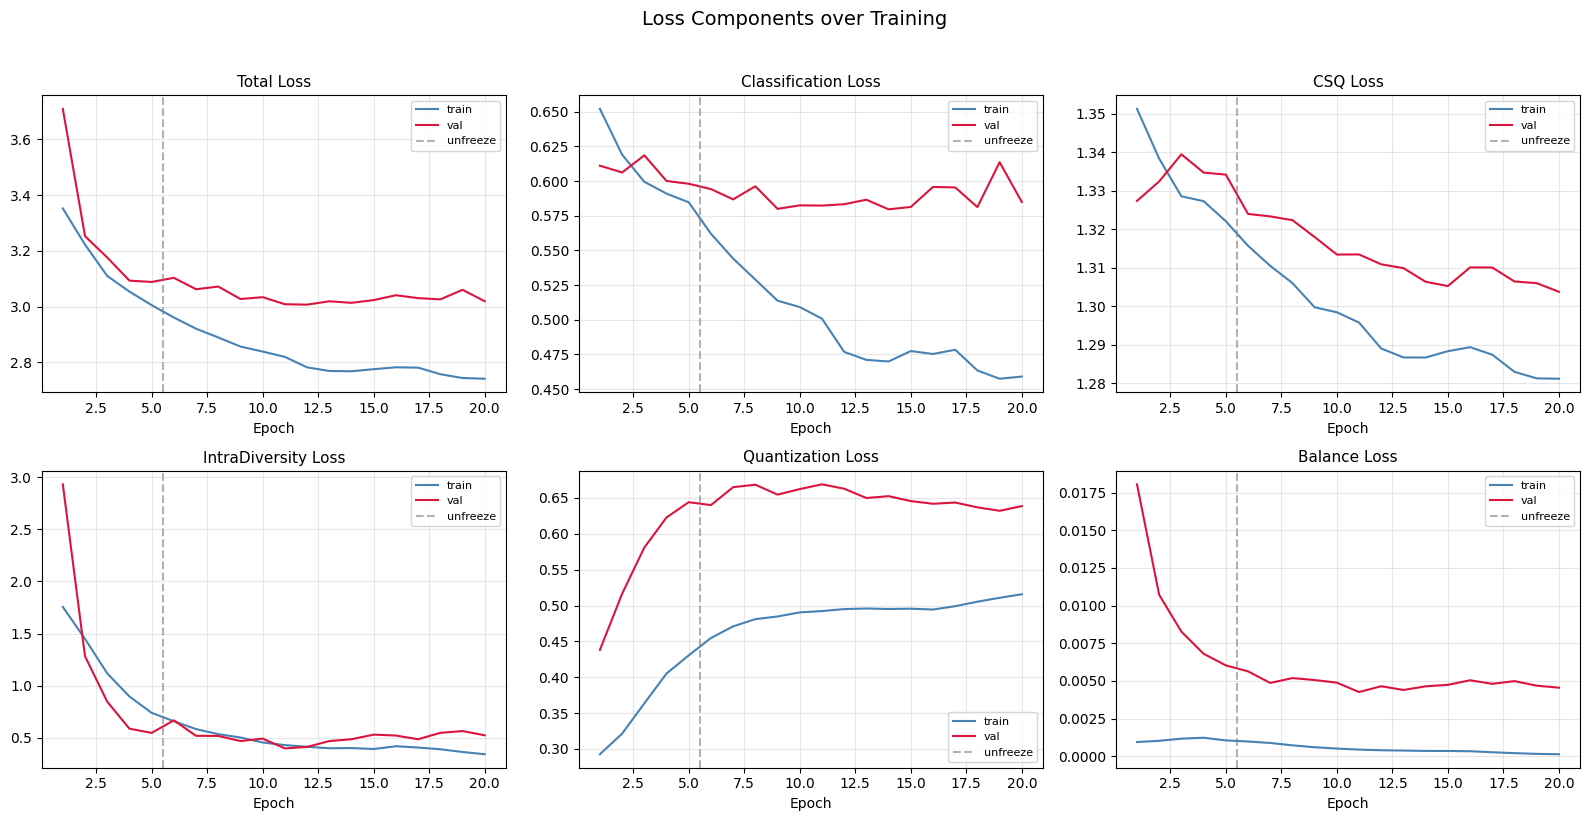

In [9]:
import pandas as pd

hist_df = pd.DataFrame(history)
unfreeze_ep = EPOCHS_FROZEN + 0.5

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

loss_panels = [
    ("loss", "Total Loss"),
    ("cls", "Classification Loss"),
    ("csq", "CSQ Loss"),
    ("div", "IntraDiversity Loss"),
    ("quant", "Quantization Loss"),
    ("balance", "Balance Loss"),
]

for (key, title), ax in zip(loss_panels, axes.flat):
    ax.plot(hist_df["epoch"], hist_df[f"tr_{key}"], label="train", color="steelblue")
    ax.plot(hist_df["epoch"], hist_df[f"val_{key}"], label="val", color="crimson")
    ax.axvline(unfreeze_ep, color="gray", linestyle="--", alpha=0.6, label="unfreeze")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Loss Components over Training", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("loss_components.png", dpi=150, bbox_inches="tight")
plt.show()

# Cell 8b: Performance Metric Curves

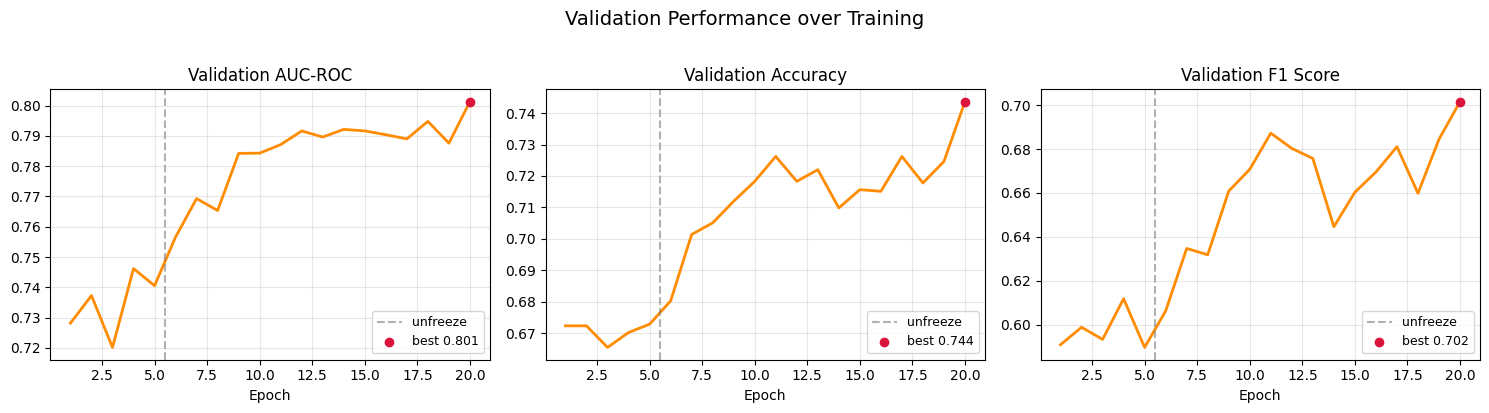

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metric_panels = [
    ("auc", "AUC-ROC"),
    ("acc", "Accuracy"),
    ("f1", "F1 Score"),
]

for (key, title), ax in zip(metric_panels, axes):
    ax.plot(hist_df["epoch"], hist_df[f"val_{key}"], linewidth=2, color="darkorange")
    ax.axvline(unfreeze_ep, color="gray", linestyle="--", alpha=0.6, label="unfreeze")
    best_ep = hist_df.loc[hist_df[f"val_{key}"].idxmax(), "epoch"]
    best_val = hist_df[f"val_{key}"].max()
    ax.scatter([best_ep], [best_val], color="crimson", zorder=5, label=f"best {best_val:.3f}")
    ax.set_title(f"Validation {title}", fontsize=12)
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("Validation Performance over Training", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# Cell 9: Test Evaluation

In [11]:
model.eval()
all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Evaluating"):
        _, logits = model(imgs.to(DEVICE))
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().float()
        all_probs.extend(probs.tolist())
        all_preds.extend(logits.argmax(1).cpu().tolist())
        all_labels.extend(labels.tolist())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

auc = roc_auc_score(all_labels, all_probs)
f1 = f1_score(all_labels, all_preds, average="binary", pos_label=1)
acc = (all_preds == all_labels).mean()
bacc = balanced_accuracy_score(all_labels, all_preds)
tp = int(((all_preds == 1) & (all_labels == 1)).sum())
tn = int(((all_preds == 0) & (all_labels == 0)).sum())
fp = int(((all_preds == 1) & (all_labels == 0)).sum())
fn = int(((all_preds == 0) & (all_labels == 1)).sum())

print(f"Test Accuracy     : {acc:.4f}")
print(f"Balanced Accuracy : {bacc:.4f}")
print(f"Test AUC-ROC      : {auc:.4f}")
print(f"Test F1           : {f1:.4f}")
print(f"Sensitivity (TPR) : {tp / (tp + fn + 1e-8):.4f}  (tampered recall)")
print(f"Specificity (TNR) : {tn / (tn + fp + 1e-8):.4f}  (authentic recall)")
print(f"TP={tp}  TN={tn}  FP={fp}  FN={fn}")
print()
print(classification_report(all_labels, all_preds, target_names=["Authentic", "Tampered"], digits=4))

Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]

Test Accuracy     : 0.7227
Balanced Accuracy : 0.7200
Test AUC-ROC      : 0.7916
Test F1           : 0.6741
Sensitivity (TPR) : 0.7061  (tampered recall)
Specificity (TNR) : 0.7340  (authentic recall)
TP=543  TN=825  FP=299  FN=226

              precision    recall  f1-score   support

   Authentic     0.7850    0.7340    0.7586      1124
    Tampered     0.6449    0.7061    0.6741       769

    accuracy                         0.7227      1893
   macro avg     0.7149    0.7200    0.7164      1893
weighted avg     0.7281    0.7227    0.7243      1893



# Cell 9b: Confsion Matrix and ROC

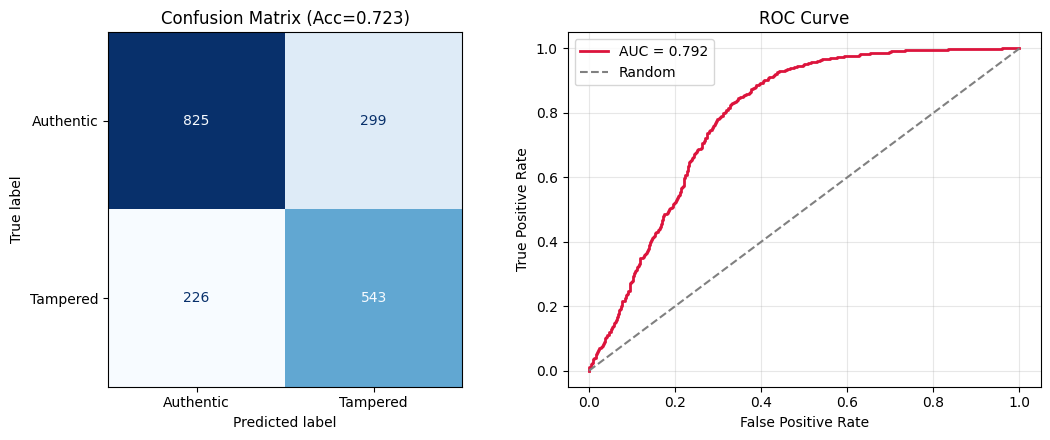

In [12]:
from sklearn.metrics import roc_curve

fpr, tpr_curve, _ = roc_curve(all_labels, all_probs)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Authentic", "Tampered"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Confusion Matrix (Acc={acc:.3f})", fontsize=12)

axes[1].plot(fpr, tpr_curve, color="crimson", linewidth=2, label=f"AUC = {auc:.3f}")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve", fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("test_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

# Cell 10: Hash Extraction

In [13]:
def extract_hashes(mdl, loader):
    mdl.eval()
    H, L = [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Extracting hashes", leave=False):
            h, _ = mdl(imgs.to(DEVICE))
            H.append(h.cpu())
            L.append(labels)
    return torch.cat(H), torch.cat(L)


test_h_cont, test_lbl = extract_hashes(model, test_loader)
test_h_bin = test_h_cont.sign()

train_full_loader = DataLoader(
    CASIADataset(train_paths, train_labels, eval_tf),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True,
)
train_h_cont, train_lbl_all = extract_hashes(model, train_full_loader)
train_h_bin = train_h_cont.sign()

print(f"Test  hashes : {test_h_bin.shape}")
print(f"Train hashes : {train_h_bin.shape}")

Extracting hashes:   0%|          | 0/60 [00:00<?, ?it/s]

Extracting hashes:   0%|          | 0/276 [00:00<?, ?it/s]

Test  hashes : torch.Size([1893, 128])
Train hashes : torch.Size([8829, 128])


# Cell 11: Hash Quality Analysis

In [14]:
saturation = test_h_cont.abs().mean().item()
per_bit_mean = test_h_bin.float().mean(dim=0).abs()
degenerate_bits = int((per_bit_mean > 0.95).sum())
bit_balance = float(per_bit_mean.mean())

au_h = test_h_bin[test_lbl == 0].float()
tp_h = test_h_bin[test_lbl == 1].float()


def intra_hamming(h: torch.Tensor, n_pairs: int = 3000) -> torch.Tensor:
    """Sample distinct random pairs and return their Hamming distances."""
    N = len(h)
    n = min(n_pairs, N * (N - 1) // 2)
    ia = torch.randint(0, N, (n * 2,))
    ib = torch.randint(0, N, (n * 2,))
    mask = ia != ib
    ia, ib = ia[mask][:n], ib[mask][:n]
    if len(ia) == 0:
        return torch.zeros(1)
    return (h[ia] != h[ib]).float().sum(1)


def inter_hamming(a: torch.Tensor, b: torch.Tensor, n_pairs: int = 3000) -> torch.Tensor:
    n = min(n_pairs, len(a), len(b))
    ia = torch.randint(0, len(a), (n,))
    ib = torch.randint(0, len(b), (n,))
    return (a[ia] != b[ib]).float().sum(1)


intra_au_dists = intra_hamming(au_h)
intra_tp_dists = intra_hamming(tp_h)
inter_dists = inter_hamming(au_h, tp_h)

intra_au = intra_au_dists.mean().item()
intra_tp = intra_tp_dists.mean().item()
inter_h = inter_dists.mean().item()
sep_ratio = inter_h / max(intra_au, intra_tp, 1e-8)

zero_intra_au = (intra_au_dists == 0).float().mean().item()
zero_intra_tp = (intra_tp_dists == 0).float().mean().item()
std_intra_au = intra_au_dists.float().std().item()
std_intra_tp = intra_tp_dists.float().std().item()

print(f"Saturation (mean |h|)          : {saturation:.4f}   (target > 0.85)")
print(f"Degenerate bits (|mean| > 0.95): {degenerate_bits}/{HASH_BITS}  (target < 5)")
print(f"Bit balance (mean |mean_bit|)   : {bit_balance:.4f}   (target < 0.05)")
print(f"Intra-class Hamming  mean       : Au={intra_au:.1f}  Tp={intra_tp:.1f}  (healthy: 30-60)")
print(f"Intra-class Hamming  std        : Au={std_intra_au:.1f}  Tp={std_intra_tp:.1f}  (healthy: <20)")
print(f"Inter-class Hamming  mean       : {inter_h:.1f}  (healthy: >60, ideally >80)")
print(f"Separability ratio              : {sep_ratio:.2f}x  (target > 1.5)")
print(f"Zero-distance pairs (collapse)  : Au={zero_intra_au:.4f}  Tp={zero_intra_tp:.4f}  (target < 0.01)")

Saturation (mean |h|)          : 0.2191   (target > 0.85)
Degenerate bits (|mean| > 0.95): 0/128  (target < 5)
Bit balance (mean |mean_bit|)   : 0.1161   (target < 0.05)
Intra-class Hamming  mean       : Au=61.7  Tp=62.0  (healthy: 30-60)
Intra-class Hamming  std        : Au=7.8  Tp=7.2  (healthy: <20)
Inter-class Hamming  mean       : 64.0  (healthy: >60, ideally >80)
Separability ratio              : 1.03x  (target > 1.5)
Zero-distance pairs (collapse)  : Au=0.0000  Tp=0.0000  (target < 0.01)


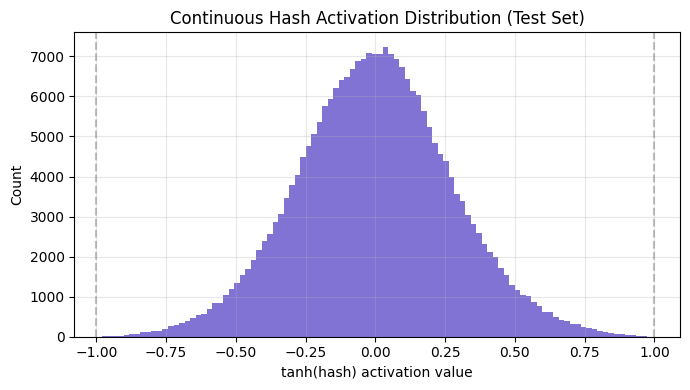

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(test_h_cont.flatten().numpy(), bins=100, color="slateblue", alpha=0.85)
ax.axvline(-1, color="gray", linestyle="--", alpha=0.5)
ax.axvline(1, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("tanh(hash) activation value")
ax.set_ylabel("Count")
ax.set_title("Continuous Hash Activation Distribution (Test Set)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("hash_activation_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

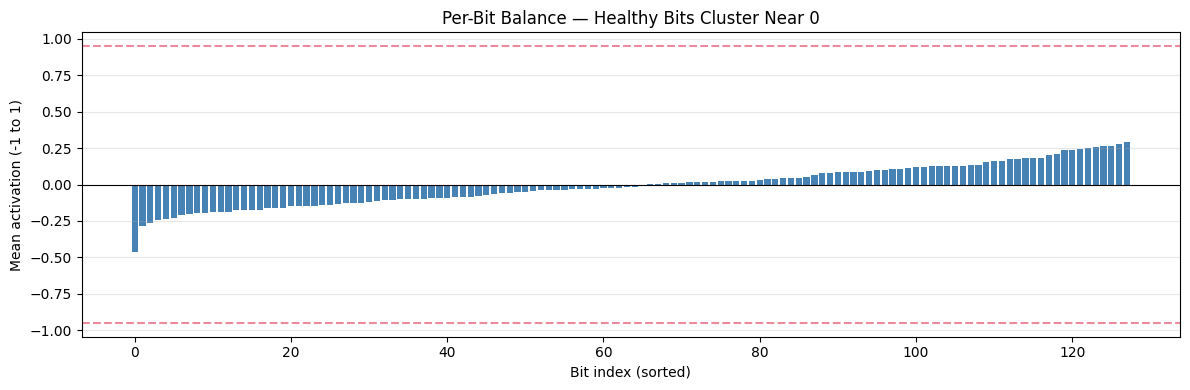

In [16]:
bit_means = test_h_bin.float().mean(dim=0).numpy()
order_b = np.argsort(bit_means)
colors = ["crimson" if abs(v) > 0.95 else "steelblue" for v in bit_means[order_b]]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(HASH_BITS), bit_means[order_b], color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(0.95, color="crimson", linestyle="--", alpha=0.5)
ax.axhline(-0.95, color="crimson", linestyle="--", alpha=0.5)
ax.set_xlabel("Bit index (sorted)")
ax.set_ylabel("Mean activation (-1 to 1)")
ax.set_title("Per-Bit Balance — Healthy Bits Cluster Near 0")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("per_bit_balance.png", dpi=150, bbox_inches="tight")
plt.show()

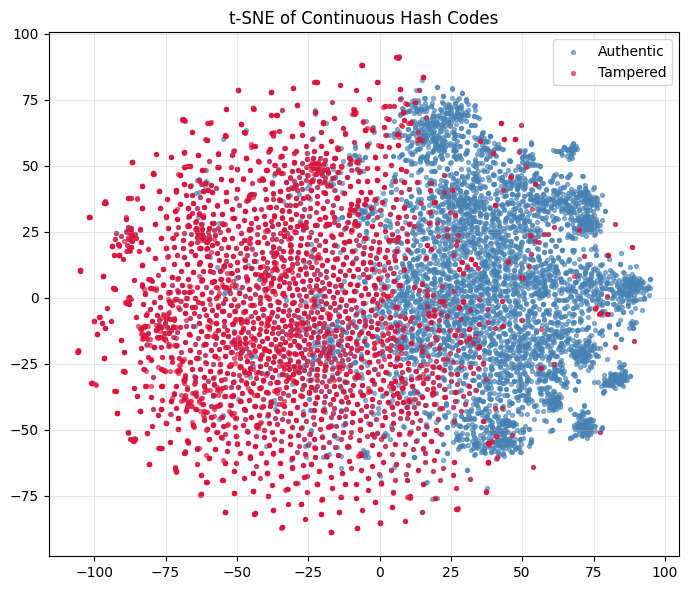

In [17]:
combined_h = torch.cat([train_h_cont, test_h_cont]).numpy()
combined_lbl = torch.cat([train_lbl_all, test_lbl]).numpy()

tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, init="pca")
emb = tsne.fit_transform(combined_h)

fig, ax = plt.subplots(figsize=(7, 6))
for cls, name, color in [(0, "Authentic", "steelblue"), (1, "Tampered", "crimson")]:
    mask = combined_lbl == cls
    ax.scatter(emb[mask, 0], emb[mask, 1], s=8, alpha=0.6, label=name, color=color)
ax.set_title("t-SNE of Continuous Hash Codes")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("hash_tsne.png", dpi=150, bbox_inches="tight")
plt.show()

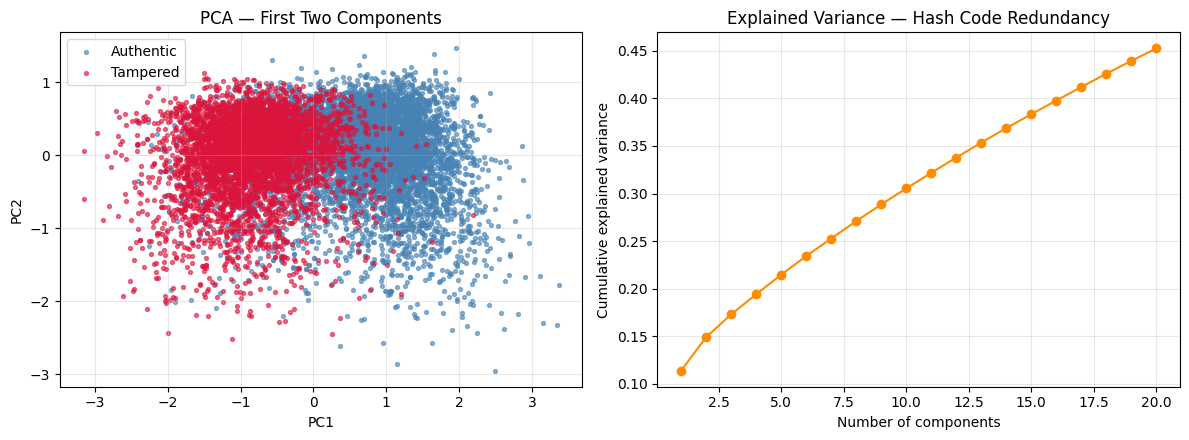

In [18]:
pca = PCA(n_components=min(20, HASH_BITS), random_state=SEED)
pca_proj = pca.fit_transform(combined_h)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for cls, name, color in [(0, "Authentic", "steelblue"), (1, "Tampered", "crimson")]:
    mask = combined_lbl == cls
    axes[0].scatter(pca_proj[mask, 0], pca_proj[mask, 1], s=8, alpha=0.6, label=name, color=color)
axes[0].set_title("PCA — First Two Components")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(np.arange(1, len(pca.explained_variance_ratio_) + 1),
             np.cumsum(pca.explained_variance_ratio_), marker="o", color="darkorange")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative explained variance")
axes[1].set_title("Explained Variance — Hash Code Redundancy")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("hash_pca.png", dpi=150, bbox_inches="tight")
plt.show()

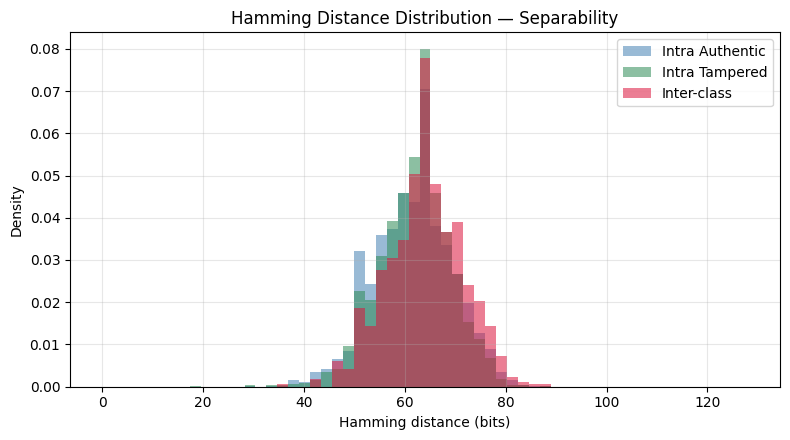

In [19]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bins = np.linspace(0, HASH_BITS, 60)
ax.hist(intra_au_dists.numpy(), bins=bins, alpha=0.55, label="Intra Authentic", color="steelblue", density=True)
ax.hist(intra_tp_dists.numpy(), bins=bins, alpha=0.55, label="Intra Tampered", color="seagreen", density=True)
ax.hist(inter_dists.numpy(), bins=bins, alpha=0.55, label="Inter-class", color="crimson", density=True)
ax.set_xlabel("Hamming distance (bits)")
ax.set_ylabel("Density")
ax.set_title("Hamming Distance Distribution — Separability")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("hamming_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

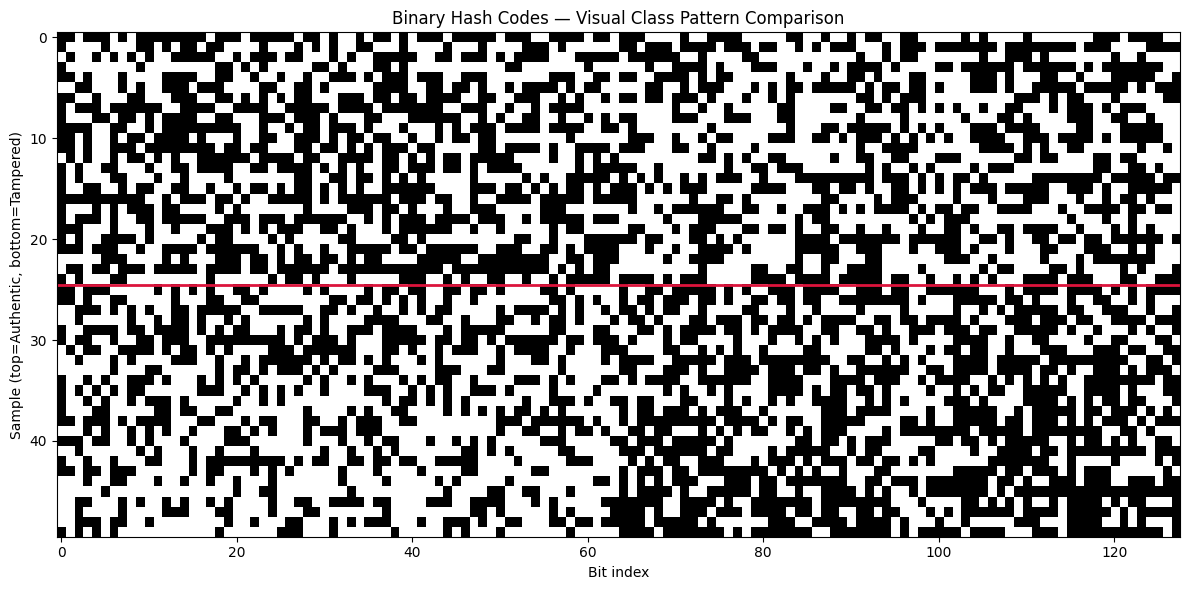

In [20]:
n_show = 25
au_idx = (test_lbl == 0).nonzero(as_tuple=True)[0][:n_show]
tp_idx = (test_lbl == 1).nonzero(as_tuple=True)[0][:n_show]
sample_codes = torch.cat([test_h_bin[au_idx], test_h_bin[tp_idx]]).numpy()

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(sample_codes, cmap="gray_r", aspect="auto")
ax.axhline(n_show - 0.5, color="crimson", linewidth=2)
ax.set_xlabel("Bit index")
ax.set_ylabel("Sample (top=Authentic, bottom=Tampered)")
ax.set_title("Binary Hash Codes — Visual Class Pattern Comparison")
plt.tight_layout()
plt.savefig("binary_codes_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

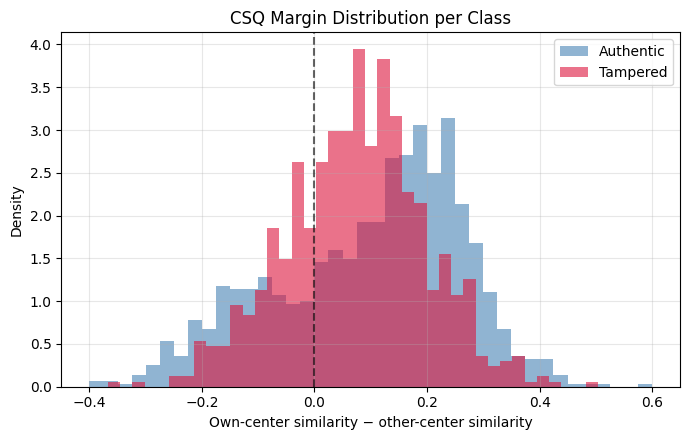

In [21]:
centers_cpu = hash_loss_fn.centers.cpu()
sim_all = test_h_cont @ centers_cpu.T / HASH_BITS
own_sim = sim_all[torch.arange(len(test_lbl)), test_lbl]
other_sim = sim_all[torch.arange(len(test_lbl)), 1 - test_lbl]
margin = (own_sim - other_sim).numpy()

fig, ax = plt.subplots(figsize=(7, 4.5))
for cls, name, color in [(0, "Authentic", "steelblue"), (1, "Tampered", "crimson")]:
    mask = (test_lbl == cls).numpy()
    ax.hist(margin[mask], bins=40, alpha=0.6, label=name, color=color, density=True)
ax.axvline(0, color="black", linestyle="--", alpha=0.6)
ax.set_xlabel("Own-center similarity − other-center similarity")
ax.set_ylabel("Density")
ax.set_title("CSQ Margin Distribution per Class")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("csq_margin_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

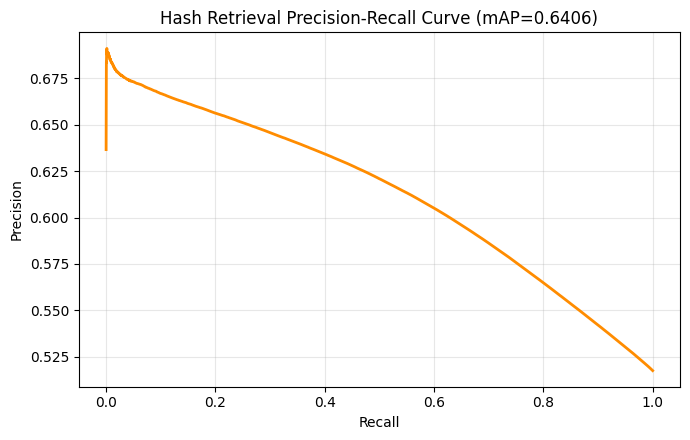

Mean Average Precision (mAP): 0.6406


In [22]:
def hamming_matrix(a, b):
    return (HASH_BITS - a @ b.T) / 2.0

gallery, gallery_lbl = train_h_bin, train_lbl_all
query, query_lbl = test_h_bin, test_lbl

dist = hamming_matrix(query, gallery)
order_r = dist.argsort(dim=1)

ranked_rel = (gallery_lbl[order_r] == query_lbl.unsqueeze(1)).float()
cum_rel = ranked_rel.cumsum(dim=1)
ranks = torch.arange(1, gallery.size(0) + 1).float()
precision_at_k = cum_rel / ranks
total_rel = ranked_rel.sum(dim=1, keepdim=True).clamp(min=1)
ap = (precision_at_k * ranked_rel).sum(dim=1) / total_rel.squeeze(1)
mAP = ap.mean().item()

mean_precision_curve = precision_at_k.mean(dim=0).numpy()
mean_recall_curve = (cum_rel / total_rel).mean(dim=0).numpy()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(mean_recall_curve, mean_precision_curve, color="darkorange", linewidth=2)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(f"Hash Retrieval Precision-Recall Curve (mAP={mAP:.4f})")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("retrieval_pr_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean Average Precision (mAP): {mAP:.4f}")

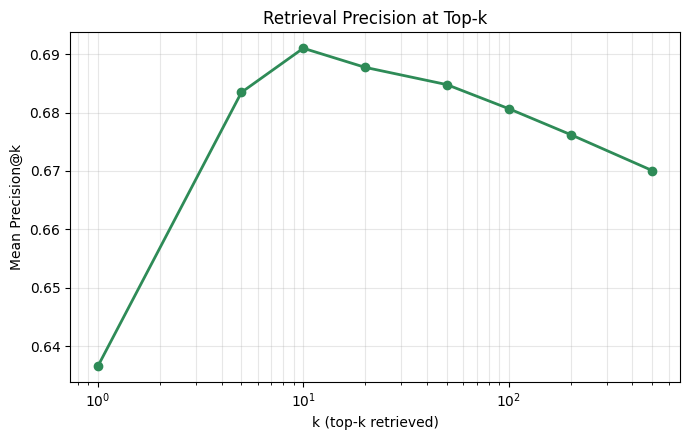

In [23]:
ks = [1, 5, 10, 20, 50, 100, 200, 500]
ks_valid = [k for k in ks if k <= precision_at_k.size(1)]
prec_at_k = [precision_at_k[:, k - 1].mean().item() for k in ks_valid]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(ks_valid, prec_at_k, marker="o", color="seagreen", linewidth=2)
ax.set_xscale("log")
ax.set_xlabel("k (top-k retrieved)")
ax.set_ylabel("Mean Precision@k")
ax.set_title("Retrieval Precision at Top-k")
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("precision_at_k.png", dpi=150, bbox_inches="tight")
plt.show()